# Chapter 6: Projective planes

Source orientation: printed pages 117-142, physical PDF pages 127-152, sections 6.1-6.8. This notebook is an original standalone lesson built from that span for orientation and coverage only; it does not copy the textbook prose, exercises, diagrams, screenshots, or page layout.

## Chapter goal

The chapter asks how incidence alone can begin to manufacture arithmetic. We treat a projective plane as a machine whose primitive data are points, lines, and incidences. Pappus and Desargues are not decorative named theorems here: they are the coincidences that make coordinate operations behave like field operations.

## Computational translation guide

| Chapter language | Computational representation | What to inspect |
| --- | --- | --- |
| Point and line | Homogeneous vectors; `join` for the line through two points; `meet` for two lines | Incidence residuals vanish when a point lies on a line |
| Pappus configuration | Six points on two lines; opposite-side intersections `X, Y, Z` | The three intersections lie on one computed line |
| Desargues configuration | Two triangles in perspective from a point | Corresponding side intersections are collinear |
| Coincidence | A forced extra incidence | Which theorem forces the extra incidence |
| Moulton-style failure | Broken positive-slope lines | A perspective-triangle construction whose side intersections are not collinear |
| Projective arithmetic | Straightedge-only parallel constructions in an affine chart | Endpoint independence from auxiliary choices |
| Field laws | Dependency matrix from geometric coincidences to algebraic laws | Pappus supplies commutativity; Desargues/scissors supplies associativity |

## Source-specific storyboard implemented

1. Exact Pappus and Desargues incidence diagrams with JSON residual checks.
2. A coincidence/proof dependency graph for Pappus, Desargues, little Desargues, converse Desargues, scissors, arithmetic well-definedness, and field laws.
3. A deterministic Moulton-plane counterexample showing why the three basic projective-plane axioms are not enough.
4. Projective addition and product diagrams, plus an HTML slider lab for auxiliary choices.
5. A finite `GF(5)` Pappus check over thousands of configurations.
6. A field-law dependency visual and a quaternion check that isolates noncommutative multiplication.
7. A Plotly 3D spatial Desargues shadow showing why the planar theorem is automatic when a true third dimension is available.

## Library routing notes

This chapter is incidence-heavy, so static Matplotlib diagrams carry the exact constructions where labels, line styles, and residual annotations matter more than motion. NetworkX is used for proof dependencies because the important object is a directed implication graph, not a picture of points. SymPy supplies exact homogeneous-coordinate checks for Pappus and Desargues, while modular arithmetic gives a finite `GF(5)` counterweight to floating-point diagrams. The Moulton section uses explicit Python functions rather than a hidden library because the broken-line rule is the mathematical object being inspected. Plotly is reserved for the spatial Desargues shadow, where rotation of the 3D scene helps the learner see the two triangle planes and their line of intersection. The small HTML arithmetic lab is plain SVG/JavaScript so the auxiliary-line and auxiliary-unit sliders remain book-local and reproducible without a server.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import permutations
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if candidate.name == "The-Four-Pillars-of-Geometry" and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate The-Four-Pillars-of-Geometry root")

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

BOOK_ROOT = find_book_root(NOTEBOOK_DIR)
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, ensure_artifact_root, image_stats, save_html, save_json, save_table
from utils.projective import incidence as numeric_incidence, join as numeric_join, meet as numeric_meet

CHAPTER_KEY = "chapter-06-projective-planes"
ARTIFACT_ROOT = ensure_artifact_root(BOOK_ROOT / "artifacts" / CHAPTER_KEY)

# The old generic visual scaffold is intentionally replaced by chapter-specific cells below.
STALE_GENERIC_ARTIFACTS = [
    "figures/visual_spine.png",
    "figures/construction_or_model.png",
    "figures/algebraic_check.png",
    "figures/invariant_heatmap.png",
    "figures/proof_state.png",
    "html/interactive_invariant_lab.html",
    "checks/invariants.json",
]
for relative in STALE_GENERIC_ARTIFACTS:
    stale = ARTIFACT_ROOT / relative
    if stale.exists():
        stale.unlink()

FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "ink":"#243040", "blue":"#1f77b4", "orange":"#d95f02", "green":"#2e8b57",
    "red":"#c74343", "purple":"#6f5bd7", "gold":"#c7971d", "gray":"#7d8790", "light":"#f7f3e8"
}
plt.rcParams.update({"font.size": 10, "axes.titlesize": 13, "axes.labelsize": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\The-Four-Pillars-of-Geometry
Artifact root: artifacts\chapter-06-projective-planes


## Incidence engine

The code below uses homogeneous coordinates for the familiar model `RP^2`, so that the constructions can be checked exactly. This is not meant to make the chapter analytic; it gives us a precise laboratory for incidence claims. The point of the Pappus and Desargues cells is that the final line is not put in by hand. It is recovered from the intersections already forced by the configuration.

In [2]:
def H(x, y, w=1):
    return sp.Matrix([sp.Rational(x), sp.Rational(y), sp.Rational(w)])

def join_exact(p, q):
    return sp.Matrix(p).cross(sp.Matrix(q))

def meet_exact(l, m):
    return sp.Matrix(l).cross(sp.Matrix(m))

def incidence_exact(p, l):
    return sp.simplify(sp.Matrix(p).dot(sp.Matrix(l)))

def affine_exact(p):
    p = sp.Matrix(p)
    if sp.simplify(p[2]) == 0:
        return None
    return (sp.simplify(p[0] / p[2]), sp.simplify(p[1] / p[2]))

def xy_float(p):
    a = affine_exact(p)
    if a is None:
        raise ValueError(f"point at infinity: {p}")
    return np.array([float(a[0]), float(a[1])], dtype=float)

def line_from_coeffs(line, xlim, ylim):
    a, b, c = [float(v) for v in line]
    points = []
    for x in xlim:
        if abs(b) > 1e-12:
            y = -(a * x + c) / b
            if ylim[0] - 1 <= y <= ylim[1] + 1:
                points.append((x, y))
    for y in ylim:
        if abs(a) > 1e-12:
            x = -(b * y + c) / a
            if xlim[0] - 1 <= x <= xlim[1] + 1:
                points.append((x, y))
    return (points[0], points[-1]) if len(points) >= 2 else None

def draw_hline(ax, line, xlim, ylim, **kwargs):
    segment = line_from_coeffs(line, xlim, ylim)
    if segment is not None:
        (x0, y0), (x1, y1) = segment
        ax.plot([x0, x1], [y0, y1], **kwargs)

def mark_points(ax, points, offsets=None, size=38):
    offsets = offsets or {}
    for label, point in points.items():
        xy = xy_float(point)
        ax.scatter([xy[0]], [xy[1]], s=size, color=PALETTE["ink"], zorder=5)
        dx, dy = offsets.get(label, (0.06, 0.06))
        ax.text(xy[0] + dx, xy[1] + dy, label, color=PALETTE["ink"], weight="bold", fontsize=9)

def finish_geometry_axes(ax, xlim, ylim):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e8dfcf", linewidth=0.7, alpha=0.8)
    ax.axhline(0, color="#b9afa0", linewidth=0.9); ax.axvline(0, color="#b9afa0", linewidth=0.9)
    ax.set_facecolor("#fffdf7")

def save_figure(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=170, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    return path

def as_jsonable_point(point):
    a = affine_exact(point)
    if a is None:
        return [str(sp.simplify(v)) for v in point]
    return [str(a[0]), str(a[1])]

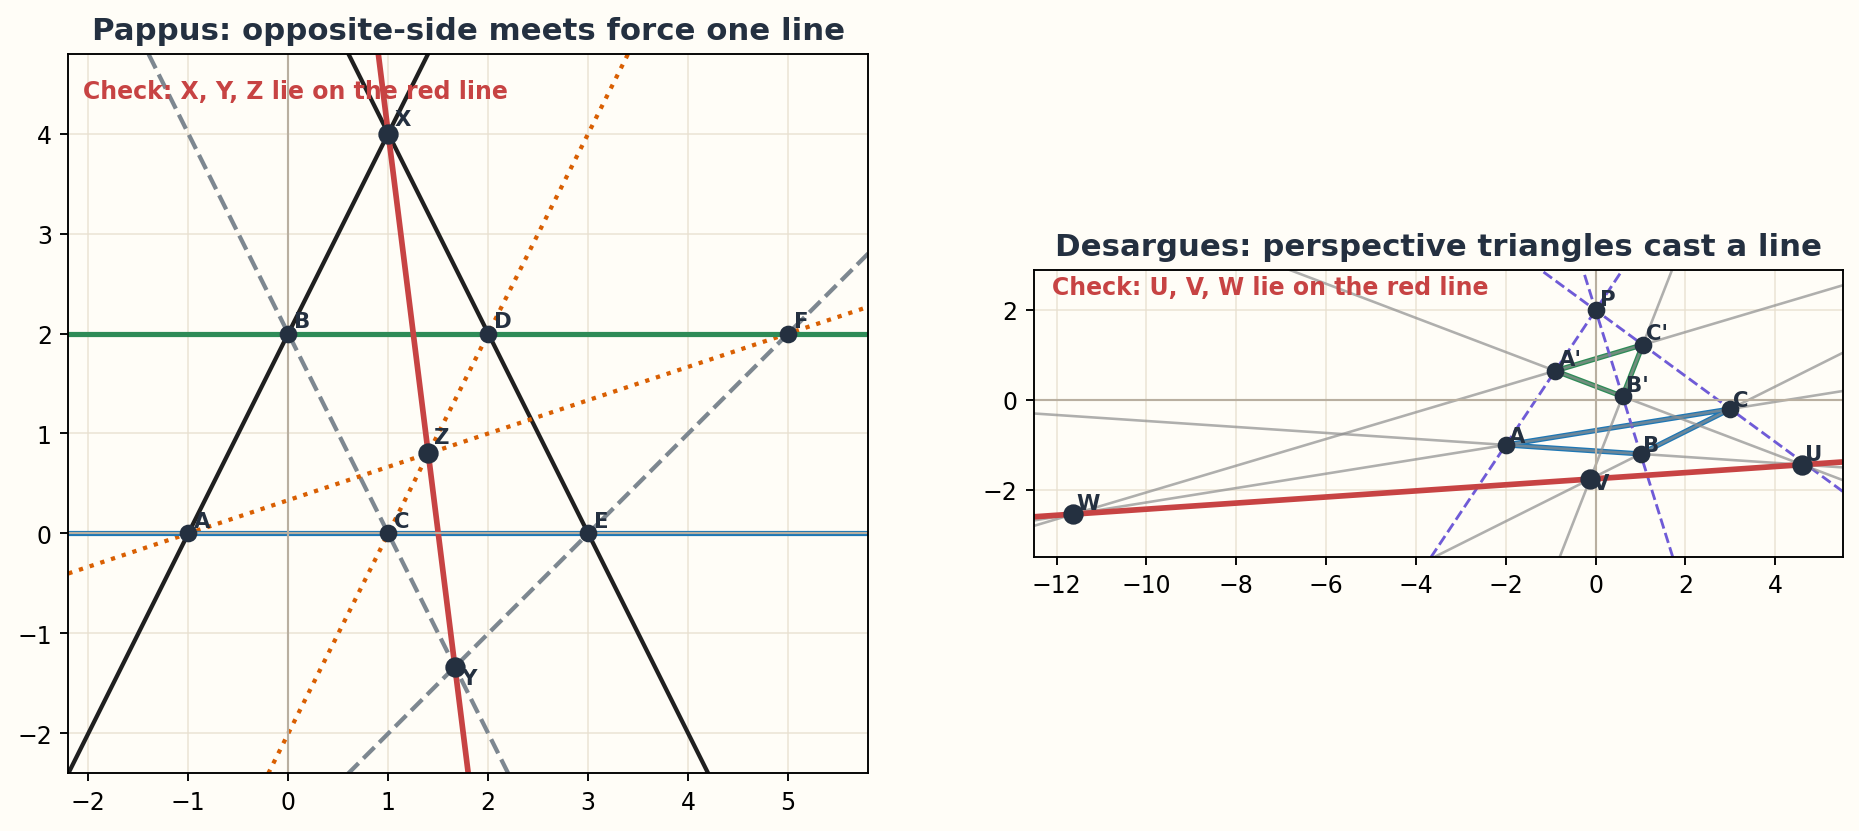

{'desargues_intersections_affine': {'U': ['23/5', '-36/25'],
  'V': ['-3/25', '-44/25'],
  'W': ['-93/8', '-127/50']},
 'desargues_residuals': {'U': '0', 'V': '0', 'W': '0'},
 'pappus_intersections_affine': {'X': ['1', '4'],
  'Y': ['5/3', '-4/3'],
  'Z': ['7/5', '4/5']},
 'pappus_residuals': {'X': '0', 'Y': '0', 'Z': '0'}}

In [3]:
def build_pappus_configuration():
    points = {"A": H(-1, 0), "C": H(1, 0), "E": H(3, 0), "B": H(0, 2), "D": H(2, 2), "F": H(5, 2)}
    intersections = {
        "X": meet_exact(join_exact(points["A"], points["B"]), join_exact(points["D"], points["E"])),
        "Y": meet_exact(join_exact(points["B"], points["C"]), join_exact(points["E"], points["F"])),
        "Z": meet_exact(join_exact(points["C"], points["D"]), join_exact(points["F"], points["A"])),
    }
    theorem_line = join_exact(intersections["X"], intersections["Y"])
    residuals = {name: incidence_exact(point, theorem_line) for name, point in intersections.items()}
    return points, intersections, theorem_line, residuals

def build_desargues_configuration():
    center = H(0, 2)
    directions = [sp.Matrix([-2, -3, 0]), sp.Matrix([1, sp.Rational(-16, 5), 0]), sp.Matrix([3, sp.Rational(-11, 5), 0])]
    points = {"P": center}
    for name, direction, scale in zip(["A", "B", "C"], directions, [sp.Rational(1), sp.Rational(1), sp.Rational(1)]):
        p = center + scale * direction
        points[name] = H(p[0], p[1])
    for name, direction, scale in zip(["A'", "B'", "C'"], directions, [sp.Rational(9, 20), sp.Rational(3, 5), sp.Rational(7, 20)]):
        p = center + scale * direction
        points[name] = H(p[0], p[1])
    intersections = {
        "U": meet_exact(join_exact(points["A"], points["B"]), join_exact(points["A'"], points["B'"])),
        "V": meet_exact(join_exact(points["B"], points["C"]), join_exact(points["B'"], points["C'"])),
        "W": meet_exact(join_exact(points["C"], points["A"]), join_exact(points["C'"], points["A'"])),
    }
    theorem_line = join_exact(intersections["U"], intersections["V"])
    residuals = {name: incidence_exact(point, theorem_line) for name, point in intersections.items()}
    return points, intersections, theorem_line, residuals

pappus_points, pappus_hits, pappus_line, pappus_residuals = build_pappus_configuration()
desargues_points, desargues_hits, desargues_line, desargues_residuals = build_desargues_configuration()
assert all(value == 0 for value in pappus_residuals.values())
assert all(value == 0 for value in desargues_residuals.values())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5), facecolor="#fffdf7")
ax = axes[0]; xlim, ylim = (-2.2, 5.8), (-2.4, 4.8)
for pair, color, style in [(("A","B"),"#202020","-"), (("D","E"),"#202020","-"), (("B","C"),PALETTE["gray"],"--"), (("E","F"),PALETTE["gray"],"--"), (("C","D"),PALETTE["orange"],":"), (("F","A"),PALETTE["orange"],":")]:
    draw_hline(ax, join_exact(pappus_points[pair[0]], pappus_points[pair[1]]), xlim, ylim, color=color, linewidth=1.8, linestyle=style)
draw_hline(ax, join_exact(pappus_points["A"], pappus_points["C"]), xlim, ylim, color=PALETTE["blue"], linewidth=2.2)
draw_hline(ax, join_exact(pappus_points["B"], pappus_points["D"]), xlim, ylim, color=PALETTE["green"], linewidth=2.2)
draw_hline(ax, pappus_line, xlim, ylim, color=PALETTE["red"], linewidth=2.4)
mark_points(ax, pappus_points, size=42)
mark_points(ax, pappus_hits, offsets={"X": (0.06,0.08), "Y": (0.06,-0.18), "Z": (0.06,0.1)}, size=58)
finish_geometry_axes(ax, xlim, ylim)
ax.set_title("Pappus: opposite-side meets force one line", color=PALETTE["ink"], weight="bold")
ax.text(-2.05, 4.35, "Check: X, Y, Z lie on the red line", color=PALETTE["red"], weight="bold")

ax = axes[1]; xlim, ylim = (-12.5, 5.5), (-3.5, 2.9)
for tri, color in [(["A","B","C","A"], PALETTE["blue"]), (["A'","B'","C'","A'"], PALETTE["green"])]:
    coords = np.array([xy_float(desargues_points[name]) for name in tri])
    ax.plot(coords[:,0], coords[:,1], color=color, linewidth=2.2)
for pair in [("P","A"),("P","B"),("P","C")]:
    draw_hline(ax, join_exact(desargues_points[pair[0]], desargues_points[pair[1]]), xlim, ylim, color=PALETTE["purple"], linewidth=1.2, linestyle="--")
for pair in [("A","B"),("A'","B'"),("B","C"),("B'","C'"),("C","A"),("C'","A'")]:
    draw_hline(ax, join_exact(desargues_points[pair[0]], desargues_points[pair[1]]), xlim, ylim, color="#8e8e8e", linewidth=1.1, alpha=0.7)
draw_hline(ax, desargues_line, xlim, ylim, color=PALETTE["red"], linewidth=2.4)
mark_points(ax, desargues_points, offsets={"P": (0.1,0.1), "A'": (0.08,0.12), "B'": (0.08,0.12), "C'": (0.08,0.12)}, size=42)
mark_points(ax, desargues_hits, offsets={"U": (0.06,0.1), "V": (0.06,-0.22), "W": (0.06,0.1)}, size=58)
finish_geometry_axes(ax, xlim, ylim)
ax.set_title("Desargues: perspective triangles cast a line", color=PALETTE["ink"], weight="bold")
ax.text(-12.1, 2.35, "Check: U, V, W lie on the red line", color=PALETTE["red"], weight="bold")

incidence_figure = save_figure(fig, "pappus-desargues-incidence-configurations.png")
incidence_checks = save_json({
    "pappus_residuals": {key: str(value) for key, value in pappus_residuals.items()},
    "pappus_intersections_affine": {key: as_jsonable_point(value) for key, value in pappus_hits.items()},
    "desargues_residuals": {key: str(value) for key, value in desargues_residuals.items()},
    "desargues_intersections_affine": {key: as_jsonable_point(value) for key, value in desargues_hits.items()},
}, ARTIFACT_ROOT, "checks", "incidence-invariants.json")
display_artifact(incidence_figure, width=960)
json.loads(incidence_checks.read_text(encoding="utf-8"))

The figure deliberately shows two levels of data. The blue and green base lines or triangles are the chosen inputs; the black, gray, orange, and purple lines are construction lines; the red line is the theorem line. The residual JSON is the invariant: in each configuration, a line determined by two constructed intersections also contains the third constructed intersection.

This is the chapter pattern. A coincidence is not a lucky drawing accident. It is a forced incidence whose proof tells us which algebraic law will be available later.

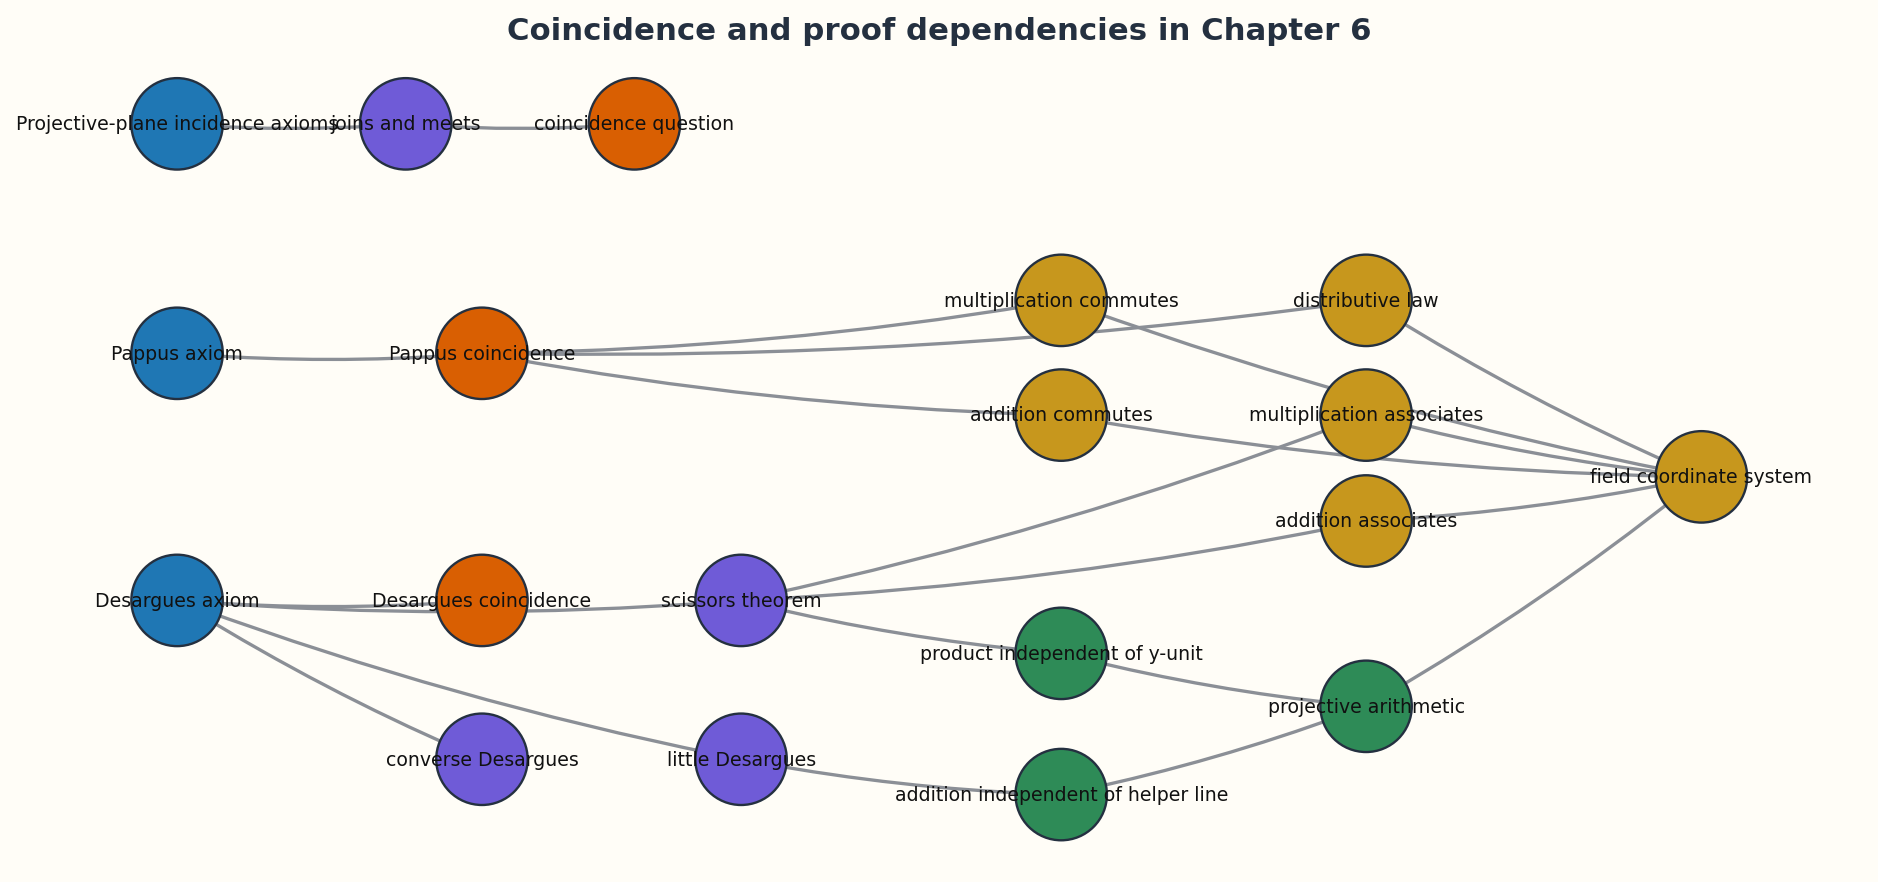

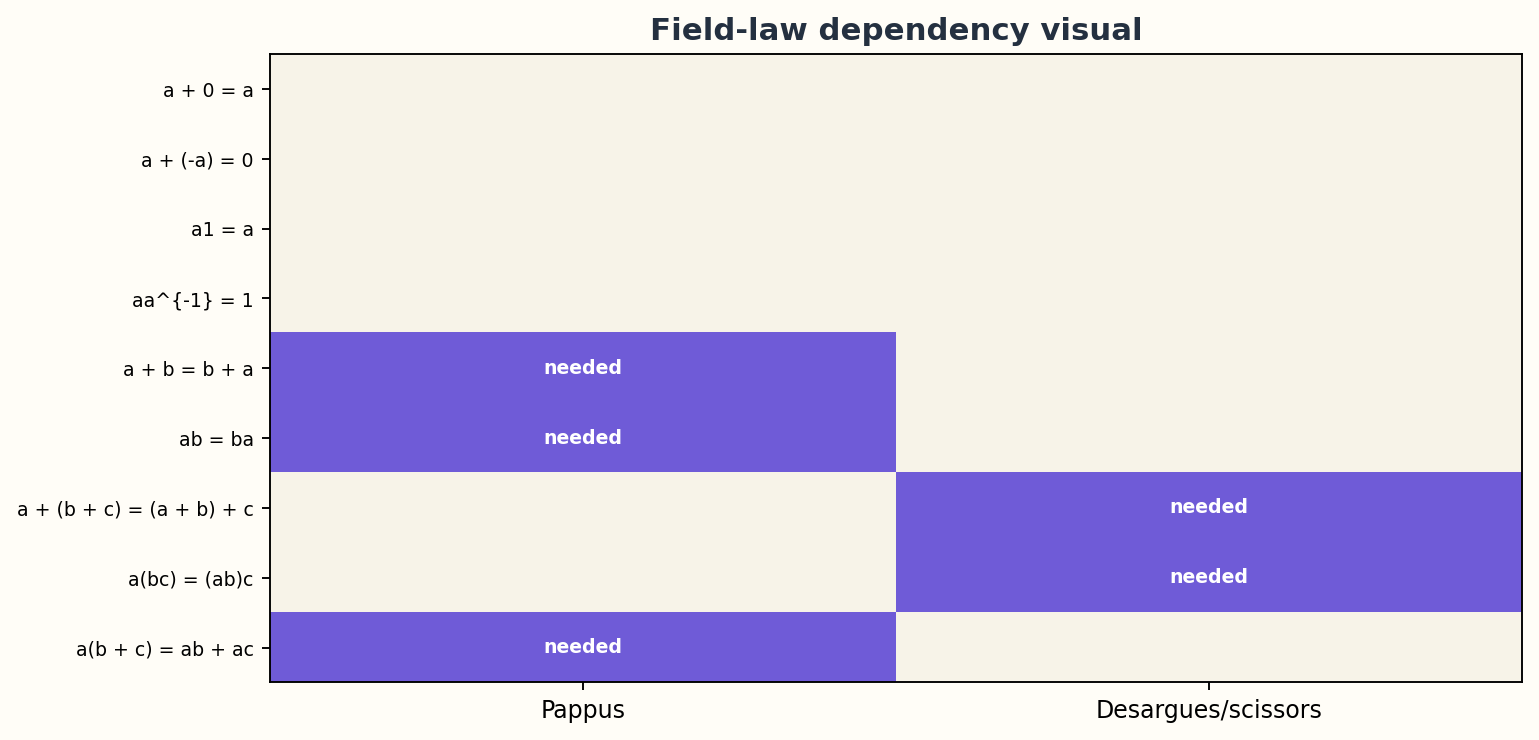

{'edge_count': 22,
 'edges': [['Projective-plane incidence axioms', 'joins and meets'],
  ['joins and meets', 'coincidence question'],
  ['Pappus axiom', 'Pappus coincidence'],
  ['Pappus coincidence', 'multiplication commutes'],
  ['Pappus coincidence', 'addition commutes'],
  ['Pappus coincidence', 'distributive law'],
  ['Desargues axiom', 'Desargues coincidence'],
  ['Desargues axiom', 'converse Desargues'],
  ['Desargues axiom', 'scissors theorem'],
  ['Desargues axiom', 'little Desargues'],
  ['scissors theorem', 'product independent of y-unit'],
  ['scissors theorem', 'addition associates'],
  ['scissors theorem', 'multiplication associates'],
  ['little Desargues', 'addition independent of helper line'],
  ['addition independent of helper line', 'projective arithmetic'],
  ['product independent of y-unit', 'projective arithmetic'],
  ['multiplication commutes', 'field coordinate system'],
  ['addition commutes', 'field coordinate system'],
  ['addition associates', 'field coord

In [4]:
proof_edges = [
    ("Projective-plane incidence axioms", "joins and meets"), ("joins and meets", "coincidence question"),
    ("Pappus axiom", "Pappus coincidence"), ("Desargues axiom", "Desargues coincidence"),
    ("Desargues axiom", "converse Desargues"), ("Desargues axiom", "scissors theorem"), ("Desargues axiom", "little Desargues"),
    ("little Desargues", "addition independent of helper line"), ("scissors theorem", "product independent of y-unit"),
    ("Pappus coincidence", "multiplication commutes"), ("Pappus coincidence", "addition commutes"),
    ("scissors theorem", "addition associates"), ("scissors theorem", "multiplication associates"), ("Pappus coincidence", "distributive law"),
    ("addition independent of helper line", "projective arithmetic"), ("product independent of y-unit", "projective arithmetic"),
    ("projective arithmetic", "field coordinate system"), ("multiplication commutes", "field coordinate system"),
    ("addition commutes", "field coordinate system"), ("addition associates", "field coordinate system"),
    ("multiplication associates", "field coordinate system"), ("distributive law", "field coordinate system"),
]
G = nx.DiGraph(proof_edges)
assert nx.is_directed_acyclic_graph(G)
positions = {
    "Projective-plane incidence axioms": (0,3), "joins and meets": (1.5,3), "coincidence question": (3,3),
    "Pappus axiom": (0,1.7), "Desargues axiom": (0,0.3), "Pappus coincidence": (2,1.7), "Desargues coincidence": (2,0.3),
    "converse Desargues": (2,-0.6), "scissors theorem": (3.7,0.3), "little Desargues": (3.7,-0.6),
    "addition independent of helper line": (5.8,-0.8), "product independent of y-unit": (5.8,0.0), "projective arithmetic": (7.8,-0.3),
    "multiplication commutes": (5.8,2.0), "addition commutes": (5.8,1.35), "addition associates": (7.8,0.75),
    "multiplication associates": (7.8,1.35), "distributive law": (7.8,2.0), "field coordinate system": (10,1.0),
}
axioms = {"Projective-plane incidence axioms", "Pappus axiom", "Desargues axiom"}
coincidences = {"coincidence question", "Pappus coincidence", "Desargues coincidence"}
tools = {"joins and meets", "converse Desargues", "scissors theorem", "little Desargues"}
arithmetic = {"addition independent of helper line", "product independent of y-unit", "projective arithmetic"}
node_colors = [PALETTE["blue"] if n in axioms else PALETTE["orange"] if n in coincidences else PALETTE["purple"] if n in tools else PALETTE["green"] if n in arithmetic else PALETTE["gold"] for n in G.nodes]
fig, ax = plt.subplots(figsize=(14, 6.2), facecolor="#fffdf7")
ax.set_facecolor("#fffdf7")
nx.draw_networkx_edges(G, positions, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#8b8f96", width=1.4, connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(G, positions, ax=ax, node_color=node_colors, node_size=1500, edgecolors=PALETTE["ink"], linewidths=1.0)
nx.draw_networkx_labels(G, positions, ax=ax, font_size=8, font_color="#111111")
ax.set_title("Coincidence and proof dependencies in Chapter 6", color=PALETTE["ink"], weight="bold")
ax.axis("off")
proof_graph_path = save_figure(fig, "coincidence-proof-dependency-graph.png")

law_rows = [
    {"law":"a + 0 = a", "geometric_source":"definition plus incidence", "requires_pappus":False, "requires_desargues":False, "notebook_check":"identity construction"},
    {"law":"a + (-a) = 0", "geometric_source":"reverse addition construction", "requires_pappus":False, "requires_desargues":False, "notebook_check":"inverse construction"},
    {"law":"a1 = a", "geometric_source":"multiplication construction", "requires_pappus":False, "requires_desargues":False, "notebook_check":"product identity"},
    {"law":"aa^{-1} = 1", "geometric_source":"reverse product construction", "requires_pappus":False, "requires_desargues":False, "notebook_check":"nonzero inverse"},
    {"law":"a + b = b + a", "geometric_source":"Pappus/little Pappus", "requires_pappus":True, "requires_desargues":False, "notebook_check":"two addition paths"},
    {"law":"ab = ba", "geometric_source":"Pappus", "requires_pappus":True, "requires_desargues":False, "notebook_check":"two product paths"},
    {"law":"a + (b + c) = (a + b) + c", "geometric_source":"little scissors", "requires_pappus":False, "requires_desargues":True, "notebook_check":"parallel scissors"},
    {"law":"a(bc) = (ab)c", "geometric_source":"scissors/Desargues", "requires_pappus":False, "requires_desargues":True, "notebook_check":"nonparallel scissors"},
    {"law":"a(b + c) = ab + ac", "geometric_source":"Pappus after axis transfer", "requires_pappus":True, "requires_desargues":False, "notebook_check":"sum-product transfer"},
]
field_table_path = save_table(law_rows, ARTIFACT_ROOT, "tables", "field-law-dependencies.csv")
fig, ax = plt.subplots(figsize=(9.5, 4.8), facecolor="#fffdf7")
labels = [row["law"] for row in law_rows]
matrix = np.array([[int(row["requires_pappus"]), int(row["requires_desargues"])] for row in law_rows], dtype=float)
ax.imshow(matrix, cmap=matplotlib.colors.ListedColormap(["#f7f3e8", "#6f5bd7"]), aspect="auto", vmin=0, vmax=1)
ax.set_xticks([0,1], labels=["Pappus", "Desargues/scissors"]); ax.set_yticks(range(len(labels)), labels=labels)
for y in range(matrix.shape[0]):
    for x in range(matrix.shape[1]):
        if matrix[y,x]:
            ax.text(x, y, "needed", ha="center", va="center", color="white", fontsize=8, weight="bold")
ax.set_title("Field-law dependency visual", color=PALETTE["ink"], weight="bold")
ax.tick_params(axis="y", labelsize=8)
field_dependency_path = save_figure(fig, "field-law-dependency-map.png")
graph_checks = save_json({"node_count": G.number_of_nodes(), "edge_count": G.number_of_edges(), "is_dag": nx.is_directed_acyclic_graph(G), "topological_order": list(nx.topological_sort(G)), "edges": list(G.edges()), "field_law_rows": len(law_rows), "field_laws": [row["law"] for row in law_rows]}, ARTIFACT_ROOT, "checks", "proof-graph-invariants.json")
display_artifact(proof_graph_path, width=980)
display_artifact(field_dependency_path, width=760)
json.loads(graph_checks.read_text(encoding="utf-8"))

The dependency graph is the proof scaffold for the rest of the notebook. It separates raw incidence axioms, named coincidence theorems, derived tools such as scissors, and the arithmetic laws they support. The matrix is deliberately narrower: it asks which named theorem carries which field-law burden. This makes the chapter's main contrast visible: Desargues is strong enough to drive associativity through scissors, while Pappus is the source of commutativity and the distribution proof used here.

## A Moulton-style failure mode

The Moulton plane keeps the same finite ordinary points as the affine plane, but positive-slope lines bend at the `x`-axis. This preserves the basic projective-plane behavior that two points determine a line and two lines meet after points at infinity are added. It does not preserve Desargues.

The next construction chooses two triangles that are in perspective from a point `P` in the Moulton sense: each pair of corresponding vertices lies on a Moulton line through `P`. In an ordinary Desargues plane the three intersections of corresponding sides would be collinear. The red residual records how far the third intersection misses the Moulton line through the first two.

In [5]:
@dataclass
class MoultonLine:
    kind: str
    m: float | None = None
    b: float | None = None
    x: float | None = None
    k: float | None = None
    c: float | None = None

    def y(self, x_value: float) -> float:
        if self.kind == "ordinary":
            return float(self.m * x_value + self.b)
        if self.kind == "broken":
            return float(self.k * (x_value - self.c)) if x_value < self.c else float(0.5 * self.k * (x_value - self.c))
        raise ValueError("vertical line has no single y-value")

    def branches(self):
        if self.kind == "ordinary":
            return [(-1e6, 1e6, float(self.m), float(self.b))]
        if self.kind == "broken":
            return [(-1e6, float(self.c), float(self.k), -float(self.k * self.c)), (float(self.c), 1e6, 0.5 * float(self.k), -0.5 * float(self.k * self.c))]
        return []

def moulton_line_through(p, q):
    x1, y1 = p; x2, y2 = q
    if abs(x1 - x2) < 1e-10:
        return MoultonLine("vertical", x=float(x1))
    ordinary_slope = (y2 - y1) / (x2 - x1)
    if ordinary_slope <= 0:
        return MoultonLine("ordinary", m=float(ordinary_slope), b=float(y1 - ordinary_slope * x1))
    factor1 = 1.0 if y1 < 0 else 0.5
    factor2 = 1.0 if y2 < 0 else 0.5
    if abs(y1) < 1e-10:
        c = x1; k = (y2 / factor2) / (x2 - c)
    elif abs(y2) < 1e-10:
        c = x2; k = (y1 / factor1) / (x1 - c)
    else:
        adjusted1 = y1 / factor1; adjusted2 = y2 / factor2
        k = (adjusted1 - adjusted2) / (x1 - x2)
        c = x1 - adjusted1 / k
    if k <= 0:
        return MoultonLine("ordinary", m=float(ordinary_slope), b=float(y1 - ordinary_slope * x1))
    return MoultonLine("broken", k=float(k), c=float(c))

def moulton_intersection(line1, line2):
    if line1.kind == "vertical" and line2.kind == "vertical":
        return None
    if line1.kind == "vertical":
        return (float(line1.x), line2.y(float(line1.x)))
    if line2.kind == "vertical":
        return (float(line2.x), line1.y(float(line2.x)))
    candidates = []
    for a1, b1, m1, c1 in line1.branches():
        for a2, b2, m2, c2 in line2.branches():
            low = max(a1, a2); high = min(b1, b2)
            if abs(m1 - m2) < 1e-10:
                continue
            x_value = (c2 - c1) / (m1 - m2)
            if low - 1e-8 <= x_value <= high + 1e-8:
                candidates.append((x_value, m1 * x_value + c1))
    if not candidates:
        return None
    candidates.sort(key=lambda item: abs(item[0]) + abs(item[1]))
    return candidates[0]

def moulton_residual(line, point):
    x_value, y_value = point
    return abs(x_value - line.x) if line.kind == "vertical" else abs(y_value - line.y(x_value))

def draw_moulton_line(ax, line, xmin, xmax, **kwargs):
    if line.kind == "vertical":
        ax.plot([line.x, line.x], ax.get_ylim(), **kwargs); return
    if line.kind == "ordinary":
        xs = np.linspace(xmin, xmax, 220)
        ax.plot(xs, [line.y(x) for x in xs], **kwargs); return
    xs1 = np.linspace(xmin, min(line.c, xmax), 120)
    xs2 = np.linspace(max(line.c, xmin), xmax, 120)
    if len(xs1):
        ax.plot(xs1, [line.y(x) for x in xs1], **kwargs)
    if len(xs2):
        ax.plot(xs2, [line.y(x) for x in xs2], **kwargs)

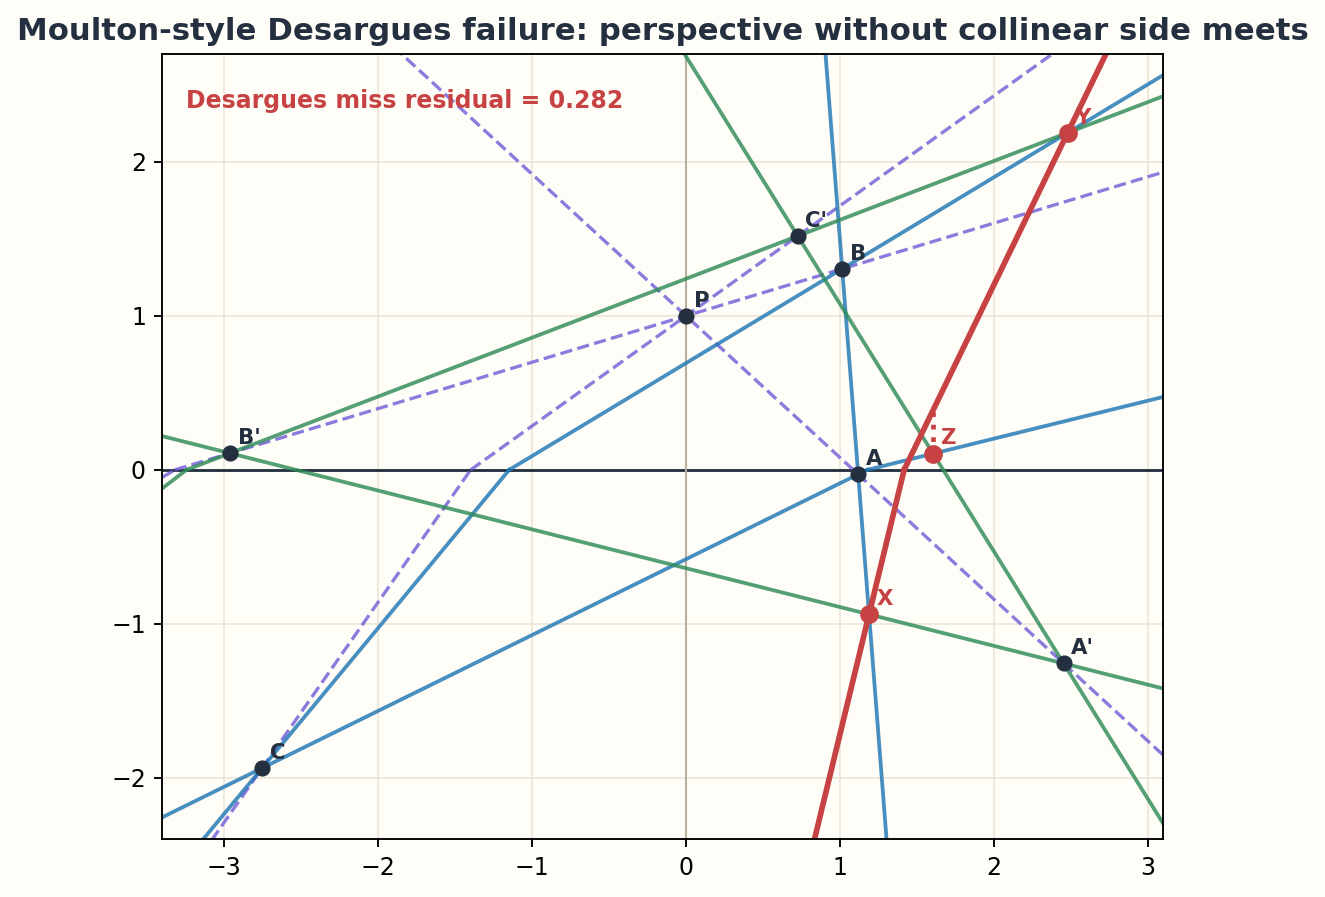

{'desargues_failure_residual_for_Z': 0.28243603315849697,
 'line_through_XY_kind': 'broken',
 'perspective_center': [0.0, 1.0],
 'ray_residuals_through_center': [0.0, 0.0, 0.0],
 'side_intersections': {'X': [1.1884765399624233, -0.9382576724236564],
  'Y': [2.4783676574262437, 2.18920329826906],
  'Z': [1.604316261068328, 0.10543777096330975]}}

In [6]:
moulton_points = {
    "P": (0.0, 1.0),
    "A": (1.1177791334379883, -0.028903594919850617),
    "A'": (2.451723140088575, -1.2567846161401492),
    "B": (1.0140454796753282, 1.3053832716123697),
    "B'": (-2.9614592778111257, 0.10814638876519919),
    "C": (-2.752932826452609, -1.9364989664061523),
    "C'": (0.7252608241322793, 1.5185358060934764),
}
side_pairs = [("A","B","A'","B'","X"), ("B","C","B'","C'","Y"), ("C","A","C'","A'","Z")]
ray_pairs = [("A","A'"), ("B","B'"), ("C","C'")]
ray_residuals = []
for p_name, q_name in ray_pairs:
    ray = moulton_line_through(moulton_points[p_name], moulton_points[q_name])
    ray_residuals.append(moulton_residual(ray, moulton_points["P"]))
assert max(ray_residuals) < 1e-8

moulton_hits = {}
for p1, p2, q1, q2, hit_name in side_pairs:
    l1 = moulton_line_through(moulton_points[p1], moulton_points[p2])
    l2 = moulton_line_through(moulton_points[q1], moulton_points[q2])
    hit = moulton_intersection(l1, l2)
    assert hit is not None
    moulton_hits[hit_name] = hit
line_xy = moulton_line_through(moulton_hits["X"], moulton_hits["Y"])
failure_residual = moulton_residual(line_xy, moulton_hits["Z"])
assert failure_residual > 0.25

fig, ax = plt.subplots(figsize=(9.5, 6), facecolor="#fffdf7")
ax.set_facecolor("#fffdf7"); ax.set_xlim(-3.4, 3.1); ax.set_ylim(-2.4, 2.7)
ax.axhline(0, color=PALETTE["ink"], linewidth=1.2); ax.axvline(0, color="#b9afa0", linewidth=0.9)
ax.grid(True, color="#e8dfcf", linewidth=0.7, alpha=0.8)
for p_name, q_name in ray_pairs:
    draw_moulton_line(ax, moulton_line_through(moulton_points[p_name], moulton_points[q_name]), -3.4, 3.1, color=PALETTE["purple"], linewidth=1.4, linestyle="--", alpha=0.8)
for tri, color in [(["A","B","C","A"], PALETTE["blue"]), (["A'","B'","C'","A'"], PALETTE["green"])]:
    for left, right in zip(tri, tri[1:]):
        draw_moulton_line(ax, moulton_line_through(moulton_points[left], moulton_points[right]), -3.4, 3.1, color=color, linewidth=1.6, alpha=0.82)
draw_moulton_line(ax, line_xy, -3.4, 3.1, color=PALETTE["red"], linewidth=2.4)
for label, point in {**moulton_points, **moulton_hits}.items():
    color = PALETTE["red"] if label in {"X","Y","Z"} else PALETTE["ink"]
    ax.scatter([point[0]], [point[1]], s=48 if label in {"X","Y","Z"} else 34, color=color, zorder=5)
    ax.text(point[0]+0.05, point[1]+0.06, label, color=color, weight="bold", fontsize=9)
z_x, z_y = moulton_hits["Z"]; z_on_line = (z_x, line_xy.y(z_x))
ax.plot([z_x, z_x], [z_y, z_on_line[1]], color=PALETTE["red"], linewidth=2.0, linestyle=":")
ax.text(-3.25, 2.35, f"Desargues miss residual = {failure_residual:.3f}", color=PALETTE["red"], weight="bold")
ax.set_title("Moulton-style Desargues failure: perspective without collinear side meets", color=PALETTE["ink"], weight="bold")
ax.set_aspect("equal", adjustable="box")
moulton_figure = save_figure(fig, "moulton-desargues-failure-counterexample.png")
moulton_checks = save_json({
    "perspective_center": moulton_points["P"],
    "ray_residuals_through_center": ray_residuals,
    "side_intersections": moulton_hits,
    "line_through_XY_kind": line_xy.kind,
    "desargues_failure_residual_for_Z": failure_residual,
}, ARTIFACT_ROOT, "checks", "moulton-counterexample.json")
display_artifact(moulton_figure, width=760)
json.loads(moulton_checks.read_text(encoding="utf-8"))

## Projective arithmetic as straightedge code

Projective addition and multiplication happen on a chosen affine `x`-axis after selecting an origin and a unit. The constructions below use only parallels in the visible affine chart, but the point is projective: the auxiliary line for addition and the auxiliary `1` on the `y`-axis must not change the endpoint. Those independence statements are exactly the sort of coincidences supplied by little Desargues and scissors.

The formulas in the checks are not replacements for the geometry. They are sanity tests that the construction diagram has the intended endpoints.

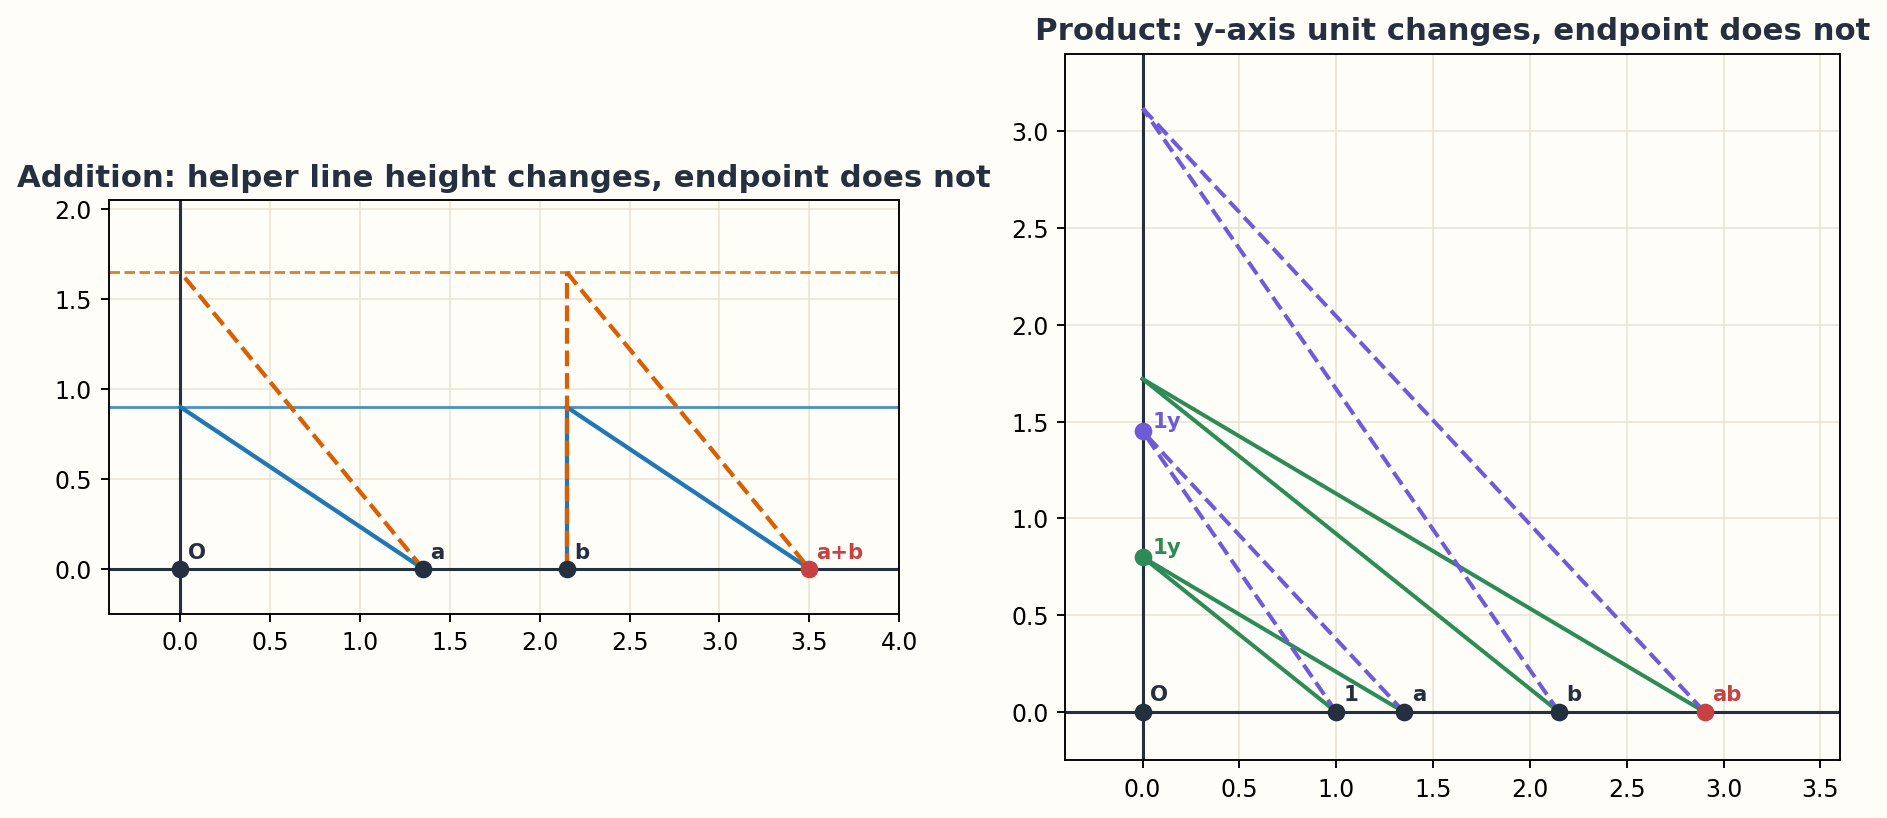

{'a': 1.35,
 'b': 2.15,
 'product_endpoint_invariant': 0.0,
 'product_endpoints': [[2.9025, 0.0], [2.9025, 0.0]],
 'product_y_units': [0.8, 1.45],
 'sum_endpoint_invariant': 0.0,
 'sum_endpoints': [[3.5, 0.0], [3.5, 0.0]],
 'sum_helper_heights': [0.9, 1.65]}

In [7]:
def construct_sum_endpoint(a, b, h):
    return {"y_axis_hit": np.array([0.0, h]), "lifted_b": np.array([b, h]), "sum": np.array([a + b, 0.0])}

def construct_product_endpoint(a, b, y_unit):
    return {"y_b": np.array([0.0, y_unit * b]), "product": np.array([a * b, 0.0]), "y_unit": np.array([0.0, y_unit])}

def draw_axes(ax, xlim, ylim):
    ax.axhline(0, color=PALETTE["ink"], linewidth=1.3); ax.axvline(0, color=PALETTE["ink"], linewidth=1.3)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.grid(True, color="#e8dfcf", linewidth=0.7, alpha=0.8)
    ax.set_aspect("equal", adjustable="box"); ax.set_facecolor("#fffdf7")

def label_point(ax, label, point, color=PALETTE["ink"], dx=0.04, dy=0.06):
    ax.scatter([point[0]], [point[1]], s=42, color=color, zorder=5)
    ax.text(point[0] + dx, point[1] + dy, label, color=color, weight="bold", fontsize=9)

a_value = 1.35; b_value = 2.15
sum_heights = [0.9, 1.65]; product_units = [0.8, 1.45]
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4), facecolor="#fffdf7")
ax = axes[0]; draw_axes(ax, (-0.4, 4.0), (-0.25, 2.05))
for h, color, style in [(sum_heights[0], PALETTE["blue"], "-"), (sum_heights[1], PALETTE["orange"], "--")]:
    ax.axhline(h, color=color, linewidth=1.2, linestyle=style, alpha=0.8)
    ax.plot([a_value, 0], [0, h], color=color, linewidth=1.8, linestyle=style)
    ax.plot([b_value, b_value], [0, h], color=color, linewidth=1.8, linestyle=style)
    ax.plot([b_value, a_value + b_value], [h, 0], color=color, linewidth=1.8, linestyle=style)
for label, point in [("O", np.array([0,0])), ("a", np.array([a_value,0])), ("b", np.array([b_value,0]))]:
    label_point(ax, label, point)
label_point(ax, "a+b", np.array([a_value + b_value, 0]), color=PALETTE["red"])
ax.set_title("Addition: helper line height changes, endpoint does not", color=PALETTE["ink"], weight="bold")

ax = axes[1]; draw_axes(ax, (-0.4, 3.6), (-0.25, 3.4))
for y_unit, color, style in [(product_units[0], PALETTE["green"], "-"), (product_units[1], PALETTE["purple"], "--")]:
    data = construct_product_endpoint(a_value, b_value, y_unit)
    ax.plot([1,0], [0,y_unit], color=color, linewidth=1.7, linestyle=style)
    ax.plot([b_value,data["y_b"][0]], [0,data["y_b"][1]], color=color, linewidth=1.7, linestyle=style)
    ax.plot([a_value,0], [0,y_unit], color=color, linewidth=1.7, linestyle=style)
    ax.plot([data["y_b"][0], a_value*b_value], [data["y_b"][1],0], color=color, linewidth=1.7, linestyle=style)
    label_point(ax, "1y", np.array([0,y_unit]), color=color, dx=0.05, dy=0.02)
for label, point in [("O", np.array([0,0])), ("1", np.array([1,0])), ("a", np.array([a_value,0])), ("b", np.array([b_value,0]))]:
    label_point(ax, label, point)
label_point(ax, "ab", np.array([a_value*b_value,0]), color=PALETTE["red"])
ax.set_title("Product: y-axis unit changes, endpoint does not", color=PALETTE["ink"], weight="bold")
arithmetic_figure = save_figure(fig, "projective-arithmetic-constructions.png")
sum_endpoints = [construct_sum_endpoint(a_value, b_value, h)["sum"].tolist() for h in sum_heights]
product_endpoints = [construct_product_endpoint(a_value, b_value, u)["product"].tolist() for u in product_units]
assert all(abs(point[0] - (a_value + b_value)) < 1e-12 for point in sum_endpoints)
assert all(abs(point[0] - (a_value * b_value)) < 1e-12 for point in product_endpoints)
arithmetic_checks = save_json({
    "a": a_value, "b": b_value, "sum_helper_heights": sum_heights, "sum_endpoints": sum_endpoints,
    "product_y_units": product_units, "product_endpoints": product_endpoints,
    "sum_endpoint_invariant": max(abs(point[0] - sum_endpoints[0][0]) for point in sum_endpoints),
    "product_endpoint_invariant": max(abs(point[0] - product_endpoints[0][0]) for point in product_endpoints),
}, ARTIFACT_ROOT, "checks", "arithmetic-construction-invariants.json")
display_artifact(arithmetic_figure, width=900)
json.loads(arithmetic_checks.read_text(encoding="utf-8"))

In [8]:
arithmetic_lab_html = r'''
<!doctype html>
<meta charset="utf-8">
<title>Projective arithmetic lab</title>
<style>
body{margin:0;font-family:Arial,sans-serif;background:#fffdf7;color:#243040}.wrap{padding:16px;max-width:980px;margin:auto}.controls{display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));gap:12px;margin-bottom:10px}label{font-size:13px;font-weight:700}input{width:100%}svg{width:100%;height:410px;border:1px solid #d8cdb9;background:white}.axis{stroke:#243040;stroke-width:2}.helper{stroke:#6f5bd7;stroke-width:2;fill:none}.product{stroke:#2e8b57;stroke-width:2;fill:none}.sum{stroke:#1f77b4;stroke-width:2;fill:none}.result{fill:#c74343;font-weight:700}.pt{fill:#243040}text{font-size:12px}
</style>
<div class="wrap"><div class="controls">
<label>a <input id="a" type="range" min="0.2" max="2.4" step="0.05" value="1.2"></label>
<label>b <input id="b" type="range" min="0.2" max="2.4" step="0.05" value="1.8"></label>
<label>addition helper height <input id="h" type="range" min="0.4" max="2.5" step="0.05" value="1.1"></label>
<label>y-axis unit <input id="u" type="range" min="0.4" max="1.8" step="0.05" value="0.9"></label>
</div><svg id="svg" viewBox="0 0 900 410" role="img" aria-label="Projective arithmetic construction lab"></svg><p id="readout"></p></div>
<script>
const svg=document.getElementById('svg');const inputs=['a','b','h','u'].map(id=>document.getElementById(id));const readout=document.getElementById('readout');
function sx(x){return 65+115*x} function sy(y){return 350-115*y}
function line(x1,y1,x2,y2,cls){const e=document.createElementNS('http://www.w3.org/2000/svg','line');e.setAttribute('x1',sx(x1));e.setAttribute('y1',sy(y1));e.setAttribute('x2',sx(x2));e.setAttribute('y2',sy(y2));e.setAttribute('class',cls);svg.appendChild(e)}
function point(x,y,label,cls='pt'){const c=document.createElementNS('http://www.w3.org/2000/svg','circle');c.setAttribute('cx',sx(x));c.setAttribute('cy',sy(y));c.setAttribute('r',4);c.setAttribute('class',cls);svg.appendChild(c);const t=document.createElementNS('http://www.w3.org/2000/svg','text');t.setAttribute('x',sx(x)+6);t.setAttribute('y',sy(y)-6);t.textContent=label;t.setAttribute('class',cls);svg.appendChild(t)}
function render(){const a=+document.getElementById('a').value,b=+document.getElementById('b').value,h=+document.getElementById('h').value,u=+document.getElementById('u').value;svg.innerHTML='';line(-0.2,0,5.2,0,'axis');line(0,-0.2,0,3.0,'axis');line(0,h,5.0,h,'helper');line(a,0,0,h,'sum');line(b,0,b,h,'sum');line(b,h,a+b,0,'sum');line(1,0,0,u,'product');line(b,0,0,u*b,'product');line(a,0,0,u,'product');line(0,u*b,a*b,0,'product');point(0,0,'O');point(1,0,'1');point(a,0,'a');point(b,0,'b');point(a+b,0,'a+b','result');point(a*b,0,'ab','result');point(0,u,'1y');readout.textContent=`a + b = ${(a+b).toFixed(2)} and ab = ${(a*b).toFixed(2)}. Move h or the y-axis unit: the construction path changes while the endpoint remains tied to the same formula.`}
inputs.forEach(el=>el.addEventListener('input',render));render();
</script>
'''
arithmetic_lab_path = save_html(arithmetic_lab_html, ARTIFACT_ROOT, "html", "projective-arithmetic-lab.html")
display_artifact(arithmetic_lab_path, width="100%", height=500)

## Finite and algebraic sanity checks

A finite field model is useful here because Pappus has no analytic wiggle room over `GF(5)`: all arithmetic is exact modulo 5, including points at infinity. We enumerate Pappus configurations with three distinct points on each of two affine lines and check that every nondegenerate case has the required collinearity.

The quaternion check is the complementary warning. Associativity and distributivity can survive while multiplication is noncommutative. That is why the chapter singles out Pappus as the source of `ab = ba` rather than treating it as another generic incidence theorem.

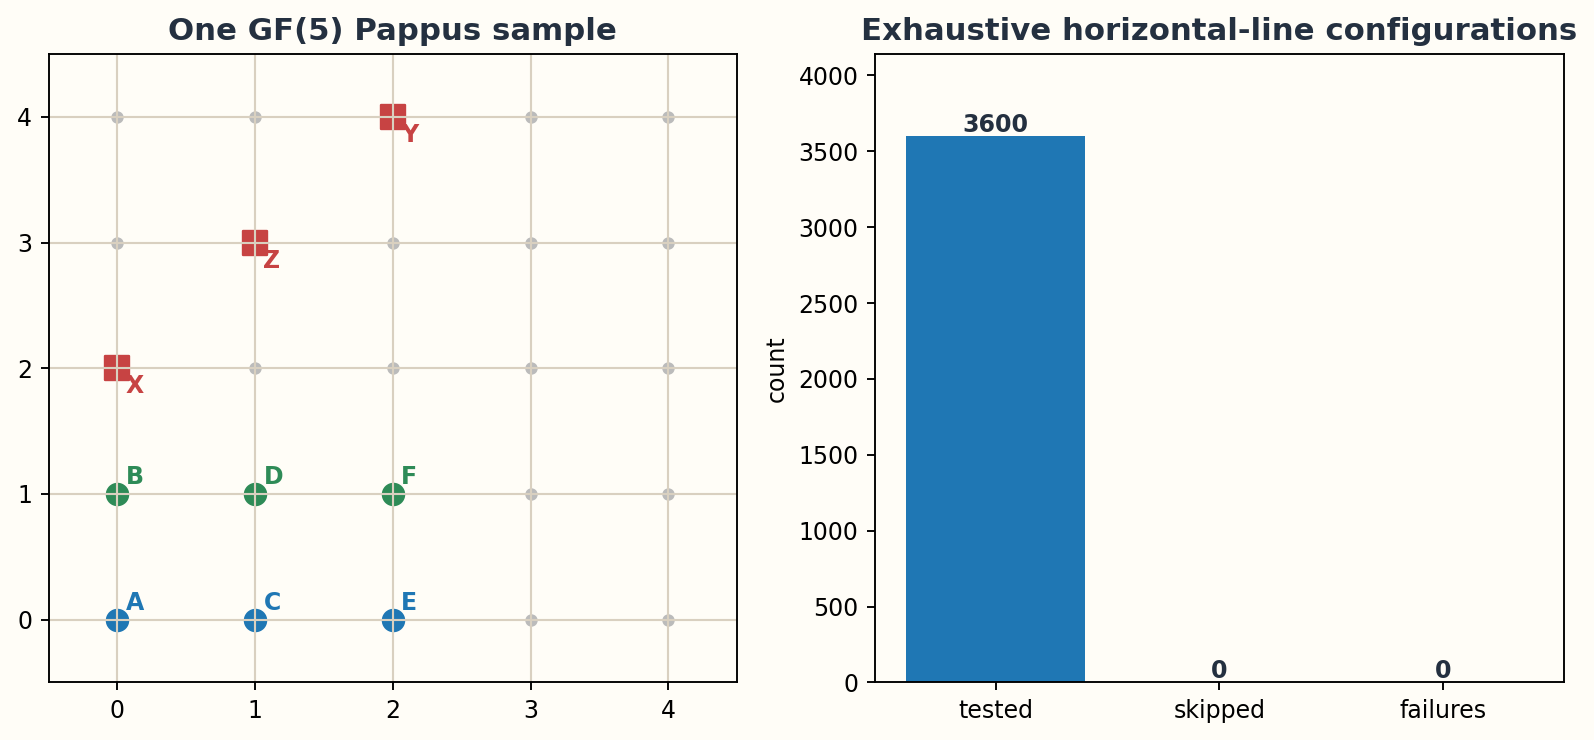

{'degenerate_configurations_skipped': 0,
 'field': 'GF(5)',
 'pappus_configurations_tested': 3600,
 'pappus_failures': 0,
 'quaternion_ij': [0, 0, 0, 1],
 'quaternion_ji': [0, 0, 0, -1],
 'quaternion_noncommutative': True,
 'sample': {'A': [0, 0, 1],
  'B': [0, 1, 1],
  'C': [1, 0, 1],
  'D': [1, 1, 1],
  'E': [2, 0, 1],
  'F': [2, 1, 1],
  'X': [0, 1, 3],
  'Y': [1, 2, 3],
  'Z': [1, 3, 1],
  'line': [1, 4, 2]}}

In [9]:
def mod_norm(v, p):
    values = tuple(int(x) % p for x in v)
    for value in values:
        if value % p:
            inv = pow(value, -1, p)
            return tuple((entry * inv) % p for entry in values)
    return values

def mod_cross(u, v, p):
    return mod_norm((u[1]*v[2]-u[2]*v[1], u[2]*v[0]-u[0]*v[2], u[0]*v[1]-u[1]*v[0]), p)

def mod_join(a, b, p): return mod_cross(a, b, p)
def mod_meet(l, m, p): return mod_cross(l, m, p)
def mod_incidence(point, line, p): return sum(point[i] * line[i] for i in range(3)) % p
def mod_affine(point, p):
    if point[2] % p == 0:
        return None
    inv = pow(point[2], -1, p)
    return ((point[0] * inv) % p, (point[1] * inv) % p)

p = 5; finite_failures = []; finite_tested = 0; finite_skipped = 0; sample = None
for xs in permutations(range(p), 3):
    for ys in permutations(range(p), 3):
        A, C, E = (xs[0],0,1), (xs[1],0,1), (xs[2],0,1)
        B, D, F = (ys[0],1,1), (ys[1],1,1), (ys[2],1,1)
        X = mod_meet(mod_join(A,B,p), mod_join(D,E,p), p)
        Y = mod_meet(mod_join(B,C,p), mod_join(E,F,p), p)
        Z = mod_meet(mod_join(C,D,p), mod_join(F,A,p), p)
        line_xy = mod_join(X,Y,p)
        if line_xy == (0,0,0):
            finite_skipped += 1; continue
        finite_tested += 1
        residual = mod_incidence(Z, line_xy, p)
        if residual != 0:
            finite_failures.append({"xs": xs, "ys": ys, "X": X, "Y": Y, "Z": Z, "residual": residual})
        if sample is None and all(mod_affine(point, p) is not None for point in [X,Y,Z]):
            sample = {"A":A, "B":B, "C":C, "D":D, "E":E, "F":F, "X":X, "Y":Y, "Z":Z, "line":line_xy}
assert not finite_failures

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), facecolor="#fffdf7")
ax = axes[0]; ax.set_facecolor("#fffdf7"); ax.set_xlim(-0.5,4.5); ax.set_ylim(-0.5,4.5)
ax.set_xticks(range(p)); ax.set_yticks(range(p)); ax.grid(True, color="#d9d0c0", linewidth=0.9)
for x in range(p):
    for y in range(p): ax.scatter([x], [y], s=18, color="#bbbbbb")
for name in ["A","C","E"]:
    x,y = mod_affine(sample[name], p); ax.scatter([x], [y], s=80, color=PALETTE["blue"]); ax.text(x+0.06,y+0.08,name,weight="bold",color=PALETTE["blue"])
for name in ["B","D","F"]:
    x,y = mod_affine(sample[name], p); ax.scatter([x], [y], s=80, color=PALETTE["green"]); ax.text(x+0.06,y+0.08,name,weight="bold",color=PALETTE["green"])
line = sample["line"]
line_points = [(x,y) for x in range(p) for y in range(p) if mod_incidence((x,y,1), line, p) == 0]
for name in ["X","Y","Z"]:
    x,y = mod_affine(sample[name], p); ax.scatter([x], [y], s=110, color=PALETTE["red"], marker="s"); ax.text(x+0.06,y-0.2,name,weight="bold",color=PALETTE["red"])
ax.set_title("One GF(5) Pappus sample", color=PALETTE["ink"], weight="bold")
ax = axes[1]; ax.set_facecolor("#fffdf7")
bars = ax.bar(["tested", "skipped", "failures"], [finite_tested, finite_skipped, len(finite_failures)], color=[PALETTE["blue"], PALETTE["gray"], PALETTE["red"]])
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, str(int(bar.get_height())), ha="center", color=PALETTE["ink"], weight="bold")
ax.set_ylim(0, max(finite_tested, finite_skipped, 1) * 1.15); ax.set_title("Exhaustive horizontal-line configurations", color=PALETTE["ink"], weight="bold"); ax.set_ylabel("count")
finite_figure = save_figure(fig, "finite-field-pappus-checks.png")

def qmul(q, r):
    a,b,c,d = q; e,f,g,h = r
    return (a*e-b*f-c*g-d*h, a*f+b*e+c*h-d*g, a*g-b*h+c*e+d*f, a*h+b*g-c*f+d*e)
i = (0,1,0,0); j = (0,0,1,0); k = (0,0,0,1); minus_k = (0,0,0,-1)
assert qmul(i,j) == k and qmul(j,i) == minus_k
finite_checks = save_json({
    "field":"GF(5)", "pappus_configurations_tested": finite_tested, "degenerate_configurations_skipped": finite_skipped,
    "pappus_failures": len(finite_failures), "sample": sample, "quaternion_ij": qmul(i,j), "quaternion_ji": qmul(j,i),
    "quaternion_noncommutative": qmul(i,j) != qmul(j,i),
}, ARTIFACT_ROOT, "checks", "finite-and-algebra-checks.json")
display_artifact(finite_figure, width=860)
json.loads(finite_checks.read_text(encoding="utf-8"))

## Spatial Desargues shadow

The closing discussion points out a reason Desargues feels different from Pappus. In three-dimensional projective space, two perspective triangles naturally live in two planes. Those planes meet in a line, and the corresponding side intersections lie on that line. A planar Desargues configuration can be regarded as a shadow of this spatial fact when the ambient projective space exists.

The HTML artifact below is interactive: rotate the scene and look for the red line where the two triangle planes meet. The three labeled side intersections sit on that same line.

In [10]:
def line_line_intersection_3d(p1, p2, q1, q2):
    p1 = np.asarray(p1, dtype=float); p2 = np.asarray(p2, dtype=float); q1 = np.asarray(q1, dtype=float); q2 = np.asarray(q2, dtype=float)
    u = p2 - p1; v = q2 - q1
    solution, *_ = np.linalg.lstsq(np.column_stack([u, -v]), q1 - p1, rcond=None)
    return p1 + solution[0] * u

center3 = np.array([0.0,0.0,4.0])
A3 = np.array([-2.0,-1.0,0.0]); B3 = np.array([2.0,-1.0,0.0]); C3 = np.array([0.0,1.6,0.0])
A3p = center3 + 0.42 * (A3 - center3); B3p = center3 + 0.62 * (B3 - center3); C3p = center3 + 0.33 * (C3 - center3)
U3 = line_line_intersection_3d(A3, B3, A3p, B3p); V3 = line_line_intersection_3d(B3, C3, B3p, C3p); W3 = line_line_intersection_3d(C3, A3, C3p, A3p)
line_residual_3d = np.linalg.norm(np.cross(V3 - U3, W3 - U3)) / np.linalg.norm(V3 - U3)
assert line_residual_3d < 1e-10
fig3 = go.Figure()
def add_polyline(points, name, color, width=5, dash=None):
    pts = np.asarray(points)
    fig3.add_trace(go.Scatter3d(x=pts[:,0], y=pts[:,1], z=pts[:,2], mode="lines+markers", name=name, line=dict(color=color, width=width, dash=dash), marker=dict(size=4)))
add_polyline([A3,B3,C3,A3], "triangle ABC", "#1f77b4")
add_polyline([A3p,B3p,C3p,A3p], "triangle A'B'C'", "#2e8b57")
for start, end, name in [(center3,A3,"ray PA"), (center3,B3,"ray PB"), (center3,C3,"ray PC")]:
    add_polyline([start,end], name, "#6f5bd7", width=3, dash="dash")
add_polyline([U3,V3,W3], "line of side intersections", "#c74343", width=7)
for label, point in {"P":center3, "U":U3, "V":V3, "W":W3}.items():
    fig3.add_trace(go.Scatter3d(x=[point[0]], y=[point[1]], z=[point[2]], mode="markers+text", text=[label], textposition="top center", marker=dict(size=6, color="#c74343" if label != "P" else "#243040"), name=label))
fig3.update_layout(title="Spatial Desargues shadow: side intersections lie on the plane-intersection line", scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"), margin=dict(l=0,r=0,t=45,b=0), legend=dict(orientation="h", yanchor="bottom", y=0.0))
spatial_html = HTML_DIR / "spatial-desargues-shadow.html"
fig3.write_html(spatial_html, include_plotlyjs=True, full_html=True)
spatial_checks = save_json({"line_residual_3d": float(line_residual_3d), "U": U3.tolist(), "V": V3.tolist(), "W": W3.tolist()}, ARTIFACT_ROOT, "checks", "spatial-desargues-checks.json")
display_artifact(spatial_html, width="100%", height=560)
json.loads(spatial_checks.read_text(encoding="utf-8"))

{'U': [5.191999999999999, -1.0, 0.0],
 'V': [2.864827586206897, -2.124275862068966, 0.0],
 'W': [-6.253333333333342, -6.529333333333344, 0.0],
 'line_residual_3d': 2.7492284265535927e-15}

## Takeaways

Pappus and Desargues are best read as incidence engines. They take a construction that appears to have several independent choices and force an endpoint or a line to coincide.

Projective arithmetic exposes the algebraic content of those engines. The construction of `a+b` needs a helper line; the construction of `ab` needs a helper unit on the `y`-axis; the laws of arithmetic require still more coincidences among different construction paths.

The Moulton example is the warning label. Basic projective-plane incidence does not by itself imply Desargues, and without Desargues the arithmetic scaffolding loses associativity and choice-independence guarantees. Pappus supplies the commutativity strength that Desargues alone does not supply.

The spatial Desargues view explains why Desargues feels natural in projective space: two planes meet in a line, so side intersections are forced onto that line. The planar theorem is the shadow of this higher-dimensional incidence fact when such a space is available.

## Final invariant checks

This last cell is intentionally strict about files and theorem claims. It checks that every named artifact exists, that PNGs are nonblank, that exact Pappus and Desargues residuals vanish, that the Moulton counterexample actually fails the Desargues collinearity test, that finite Pappus has no failures over the enumerated `GF(5)` family, and that the arithmetic endpoints are invariant under auxiliary choices.

In [11]:
manifest = {
    "figures": [
        "figures/pappus-desargues-incidence-configurations.png",
        "figures/coincidence-proof-dependency-graph.png",
        "figures/field-law-dependency-map.png",
        "figures/moulton-desargues-failure-counterexample.png",
        "figures/projective-arithmetic-constructions.png",
        "figures/finite-field-pappus-checks.png",
    ],
    "html": ["html/projective-arithmetic-lab.html", "html/spatial-desargues-shadow.html"],
    "checks": [
        "checks/incidence-invariants.json", "checks/proof-graph-invariants.json", "checks/moulton-counterexample.json",
        "checks/arithmetic-construction-invariants.json", "checks/finite-and-algebra-checks.json", "checks/spatial-desargues-checks.json",
    ],
    "tables": ["tables/field-law-dependencies.csv"],
}
manifest_path = save_json(manifest, ARTIFACT_ROOT, "checks", "artifact_manifest.json")
all_artifact_paths = [ARTIFACT_ROOT / relative for group in manifest.values() for relative in group] + [manifest_path]
assert_artifacts(all_artifact_paths, min_size=128)
png_stats = [image_stats(ARTIFACT_ROOT / relative) for relative in manifest["figures"]]
assert all(item["pixel_std"] > 2.0 for item in png_stats)
incidence_data = json.loads((CHECK_DIR / "incidence-invariants.json").read_text(encoding="utf-8"))
assert all(value == "0" for value in incidence_data["pappus_residuals"].values())
assert all(value == "0" for value in incidence_data["desargues_residuals"].values())
moulton_data = json.loads((CHECK_DIR / "moulton-counterexample.json").read_text(encoding="utf-8"))
assert max(moulton_data["ray_residuals_through_center"]) < 1e-8
assert moulton_data["desargues_failure_residual_for_Z"] > 0.25
arithmetic_data = json.loads((CHECK_DIR / "arithmetic-construction-invariants.json").read_text(encoding="utf-8"))
assert arithmetic_data["sum_endpoint_invariant"] < 1e-12
assert arithmetic_data["product_endpoint_invariant"] < 1e-12
finite_data = json.loads((CHECK_DIR / "finite-and-algebra-checks.json").read_text(encoding="utf-8"))
assert finite_data["pappus_failures"] == 0
assert finite_data["quaternion_noncommutative"] is True
spatial_data = json.loads((CHECK_DIR / "spatial-desargues-checks.json").read_text(encoding="utf-8"))
assert spatial_data["line_residual_3d"] < 1e-10
{"artifact_count": len(all_artifact_paths), "png_count": len(png_stats), "finite_pappus_tested": finite_data["pappus_configurations_tested"], "moulton_failure_residual": round(moulton_data["desargues_failure_residual_for_Z"], 6), "spatial_residual": spatial_data["line_residual_3d"]}

{'artifact_count': 16,
 'png_count': 6,
 'finite_pappus_tested': 3600,
 'moulton_failure_residual': 0.282436,
 'spatial_residual': 2.7492284265535927e-15}